In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

In [2]:
load_dotenv()  # Load environment variables from .env file

True

In [3]:
generator_llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash")
evaluator_llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
optimizer_llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash")

In [57]:
#state definition
class TweetState(TypedDict):
    topic: str
    iteration: int
    tone: Literal["funny", "serious", "informative"]
    content: str
    evaluation: Literal["approved", "needs improvement"]
    max_tries: int
    feedback: Annotated[str, "Feedback from the evaluator on how to improve the tweet."]

In [58]:
graph = StateGraph(TweetState)

In [59]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser, StrOutputParser
from langchain_core.messages import SystemMessage, HumanMessage

def generate_tweet(state: TweetState):
    topic = state["topic"]
    tone = state["tone"]
    parser = StrOutputParser()
    max_tries = state['max_tries']
    iteration = state['iteration']

    messages = [
        HumanMessage(content=f"""Generate a tweet about the topic provided, following the rules specified.
        Write a tweet about {topic} in more than 100 words.      
        """),
    ]

    chain = generator_llm | parser
    tweet = chain.invoke(messages)
    return {"content" : tweet}



In [60]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs improvement"]
    feedback: str = Field(..., description="Contructive Feedback from the evaluator on how to improve the tweet.")

structured_evaluator = evaluator_llm.with_structured_output(TweetEvaluation)

In [61]:
def evaluate_tweet(state: TweetState):
    content = state["content"]
    messages = [
        SystemMessage(content="You are an expert content evaluator proficient in evaluating social media content for engagement, clarity, and adherence to guidelines."),
        HumanMessage(content=f"""Evaluate the following tweet based on the rules specified.
        Tweet: {content}

        Rules:
        - Reject if in question-answer format or if it is a question.
        - Check if the tweet is original and does not copy existing content.
        - Ensure it is within 300 characters.
        - Assess if the language is simple and clear.
        - Provide feedback on how to improve the tweet if necessary.
        
        """),
    ]

    chain = structured_evaluator  
    response = chain.invoke(messages)
    return {"evaluation" : response.evaluation, "feedback" : response.feedback}

In [62]:
def optimize_tweet(state: TweetState):
    content = state["content"]
    feedback = state["feedback"]
    parser = StrOutputParser()

    messages = [
        SystemMessage(content="You are an expert content optimizer proficient in improving social media content based on feedback."),
        HumanMessage(content=f"""Optimize the following tweet based on the feedback provided.
        Tweet: {content}
        Feedback: {feedback}
        Tonality: {state['tone']}

        Rules:
        - Make necessary changes to improve the tweet while maintaining its original intent.
        - Ensure it adheres to the original guidelines:
        - Original Rules:
                - Not in question-ans format.
                - Do NOT copy or reproduce any existing content.
                - Max 300 characters per tweet.
                - Use simple, clear language.
        """),
    ]

    chain = optimizer_llm | parser
    optimized_tweet = chain.invoke(messages)
    return {"content" : optimized_tweet, "iteration" : state["iteration"] + 1}

In [63]:
graph.add_node("generate_tweet" , generate_tweet)
graph.add_node("evaluate_tweet" , evaluate_tweet)
graph.add_node("optimize_tweet" , optimize_tweet)

In [64]:
graph.add_edge(START, "generate_tweet")
graph.add_edge("generate_tweet", "evaluate_tweet")

In [65]:
def check_evaluation(state: TweetState):
    if state["evaluation"] == "approved":
        return END
    elif state["evaluation"] == "needs improvement" and state["iteration"] < state["max_tries"]:
        return "optimize_tweet"
    else:
        return END

In [66]:
graph.add_conditional_edges("evaluate_tweet", check_evaluation)

In [67]:
graph.add_edge("optimize_tweet", "evaluate_tweet")

In [68]:
workflow = graph.compile()

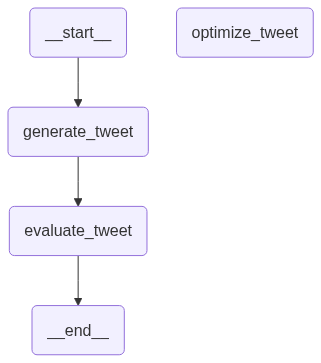

In [69]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [70]:
input_state = {
    "topic": "RAM Prices Hike",
    "iteration": 0,
    "tone": "funny",
    "content": "",
    "evaluation": "",
    "max_tries": 3,
    "feedback": ""
}

In [71]:
final_state = workflow.invoke(input_state)

In [72]:
print("Final Tweet Content:", final_state["content"])

Final Tweet Content: My wallet is officially crying. 😭 RAM makers are slashing supply while AI hoards all the DDR5, triggering a massive price hike. Buy your memory now before you have to start trading organs for a basic PC upgrade. 💸 #PCMR #TechNews


In [73]:
for field, value in final_state.items():
    if(field != "content"):
        print(f"{field}: {value}")

topic: RAM Prices Hike
iteration: 1
tone: funny
evaluation: approved
max_tries: 3
feedback: The tweet is engaging, clear, concise, well within the character limit, and effectively communicates the issue without using a question format.
